##***Shahid Patel | 31 | 232A004***

**Experiment 1: Implementing a simple grid-world environment and training an agent using basic Q-learning**



Teach a Taxi to pick up and drop off passengers at the right locations with Reinforcement Learning

**1. Import dependencies**

In [4]:
# Shahid Patel | 31 | 232A004
import os
import gymnasium as gym
import numpy as np

In [5]:
# Shahid Patel | 31 | 232A004
env = gym.make("Taxi-v3", render_mode="rgb_array")


In [6]:
# Shahid Patel | 31 | 232A004
state = env.reset()

In [7]:
# Shahid Patel | 31 | 232A004
state

(128, {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)})

In [8]:
# Shahid Patel | 31 | 232A004
env.observation_space.n

np.int64(500)

In [9]:
# Shahid Patel | 31 | 232A004
env.action_space.n

np.int64(6)

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
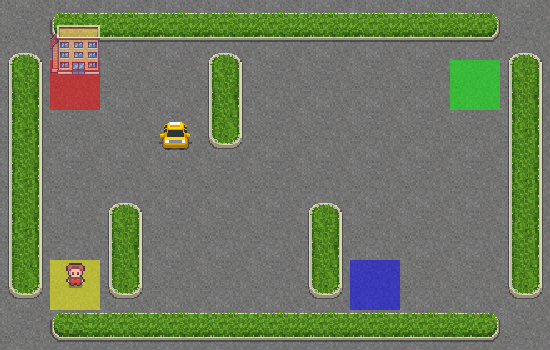

In [10]:
# Shahid Patel | 31 | 232A004
env.render()

**3. Possible actions**

**down(0), up(1), right(2), left(3), pick-up(4) and drop-off(5)**

In [11]:
# Shahid Patel | 31 | 232A004
n_states = env.observation_space.n
n_actions = env.action_space.n


In [12]:
# Shahid Patel | 31 | 232A004
n_actions


np.int64(6)

In [13]:
# Shahid Patel | 31 | 232A004
n_states


np.int64(500)

In [14]:
# Shahid Patel | 31 | 232A004
env.s=100

**4. How good does behaving completely random do?**

In [15]:
# Shahid Patel | 31 | 232A004
state = env.reset()
counter = 0
g = 0
reward = None


In [16]:
# Shahid Patel | 31 | 232A004
while reward != 20:
    state, reward, terminated, truncated, info = env.step(env.action_space.sample())
    counter += 1
    g += reward

In [17]:
# Shahid Patel | 31 | 232A004
print("Solved in {} steps with a total reward of {}".format(counter, g))


Solved in 7327 steps with a total reward of -28123


In [18]:
# Shahid Patel | 31 | 232A004
Q = np.zeros([n_states, n_actions])

In [19]:
# Shahid Patel | 31 | 232A004
n_actions

np.int64(6)

In [20]:
# Shahid Patel | 31 | 232A004
episodes = 1
G = 0
alpha = 0.618

In [21]:
# Shahid Patel | 31 | 232A004
for episode in range(1, episodes + 1):
    done = False
    G, reward = 0, 0
    state, _ = env.reset() # Modified to unpack the observation and discard the info dictionary
    finalState = state
    print("Initial State {}".format(state))
    while reward != 20:
        action = np.argmax(Q[state])
        state2, reward, terminated, truncated, info = env.step(action)
        Q[state, action] += alpha * (reward + np.max(Q[state2]) - Q[state, action])
        G += reward
        state = state2

Initial State 391


In [22]:
# Shahid Patel | 31 | 232A004
finalState = state

In [23]:
# Shahid Patel | 31 | 232A004
finalState

475

In [24]:
# Shahid Patel | 31 | 232A004
G

-1127

**Let's run over multiple episode so that we can converge on optimal policy**

In [25]:
# Shahid Patel | 31 | 232A004
episodes = 2000
# rewardTracker = []
G = 0
alpha = 0.618

for episode in range(1, episodes + 1):
    # env.reset() now returns a tuple (observation, info), unpack it
    state, _ = env.reset()
    done = False
    G, reward = 0, 0

    while not done:
        action = np.argmax(Q[state])
        # env.step() now returns (observation, reward, terminated, truncated, info)
        state2, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated # An episode is done if terminated or truncated
        # rewardTracker=rewardTracker.append(reward)
        Q[state, action] += alpha * (reward + (np.max(Q[state2]) - Q[state, action]))
        G += reward
        state = state2

    if episode % 100 == 0:
        print(f"Episode {episode} Total Reward: {G}")

Episode 100 Total Reward: -259
Episode 200 Total Reward: -16
Episode 300 Total Reward: 0
Episode 400 Total Reward: 5
Episode 500 Total Reward: -2
Episode 600 Total Reward: 10
Episode 700 Total Reward: 8
Episode 800 Total Reward: 7
Episode 900 Total Reward: 9
Episode 1000 Total Reward: 5
Episode 1100 Total Reward: 5
Episode 1200 Total Reward: 11
Episode 1300 Total Reward: 3
Episode 1400 Total Reward: 6
Episode 1500 Total Reward: 12
Episode 1600 Total Reward: 5
Episode 1700 Total Reward: 6
Episode 1800 Total Reward: 9
Episode 1900 Total Reward: 9
Episode 2000 Total Reward: 3


In [26]:
# Shahid Patel | 31 | 232A004
episodes = 2000
rewardTracker=[]
G = 0
alpha = 0.618

for episode in range(1, episodes + 1):
    done = False
    G, reward = 0, 0
    state, _ = env.reset() # Correctly unpack the observation

    while not done:
        action = np.argmax(Q[state])
        state2, reward, terminated, truncated, info = env.step(action) # Unpack all 5 return values
        done = terminated or truncated # Set done based on new termination flags
        rewardTracker.append(reward)
        Q[state, action] += alpha * (reward + (np.max(Q[state2]) - Q[state, action]))
        G += reward
        state = state2

    if episode % 50 == 0:
        print(f"Episode {episode} Total Reward: {G}")

Episode 50 Total Reward: 6
Episode 100 Total Reward: 5
Episode 150 Total Reward: 8
Episode 200 Total Reward: 5
Episode 250 Total Reward: 6
Episode 300 Total Reward: 11
Episode 350 Total Reward: 4
Episode 400 Total Reward: 8
Episode 450 Total Reward: 11
Episode 500 Total Reward: 7
Episode 550 Total Reward: 14
Episode 600 Total Reward: 8
Episode 650 Total Reward: 14
Episode 700 Total Reward: 5
Episode 750 Total Reward: 3
Episode 800 Total Reward: 14
Episode 850 Total Reward: 7
Episode 900 Total Reward: 10
Episode 950 Total Reward: 5
Episode 1000 Total Reward: 8
Episode 1050 Total Reward: 9
Episode 1100 Total Reward: 6
Episode 1150 Total Reward: 10
Episode 1200 Total Reward: 8
Episode 1250 Total Reward: 9
Episode 1300 Total Reward: 9
Episode 1350 Total Reward: 5
Episode 1400 Total Reward: 9
Episode 1450 Total Reward: 8
Episode 1500 Total Reward: 10
Episode 1550 Total Reward: 8
Episode 1600 Total Reward: 5
Episode 1650 Total Reward: 7
Episode 1700 Total Reward: 6
Episode 1750 Total Reward: